In [56]:
import os
import struct
import numpy as np

def load_mnist(path, kind='train'):
    """Load MNIST data from `path`"""
    labels_path = os.path.join(path, '%s-labels-idx1-ubyte' % kind)
    images_path = os.path.join(path, '%s-images-idx3-ubyte' % kind)
        
    with open(labels_path, 'rb') as lbpath:
        magic, n = struct.unpack('>II', lbpath.read(8))
        labels = np.fromfile(lbpath, dtype=np.uint8)

    with open(images_path, 'rb') as imgpath:
        magic, num, rows, cols = struct.unpack(">IIII", imgpath.read(16))
        images = np.fromfile(imgpath, dtype=np.uint8).reshape(len(labels), 784)
        images = ((images / 255) - .5) * 2
 
    return images, labels

In [57]:
X_train, y_train = load_mnist('datasets/', kind='train')
print('Rows: %d, columns: %d' % (X_train.shape[0], X_train.shape[1]))

X_test, y_test = load_mnist('datasets/', kind='t10k')
print('Rows: %d, columns: %d' % (X_test.shape[0], X_test.shape[1]))

Rows: 60000, columns: 784
Rows: 10000, columns: 784


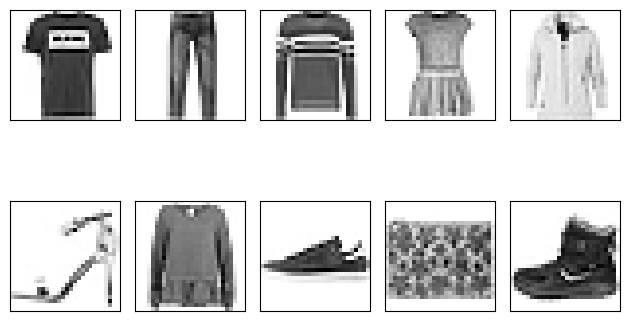

In [58]:
%matplotlib inline
import matplotlib.pyplot as plt

fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey= True)

ax = ax.flatten()

for i in range(10):
    img = X_train[y_train == i][0].reshape(28,28)
    ax[i].imshow(img, cmap='Greys')
    
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [59]:
!mkdir save_data

mkdir: no se puede crear el directorio «save_data»: El archivo ya existe


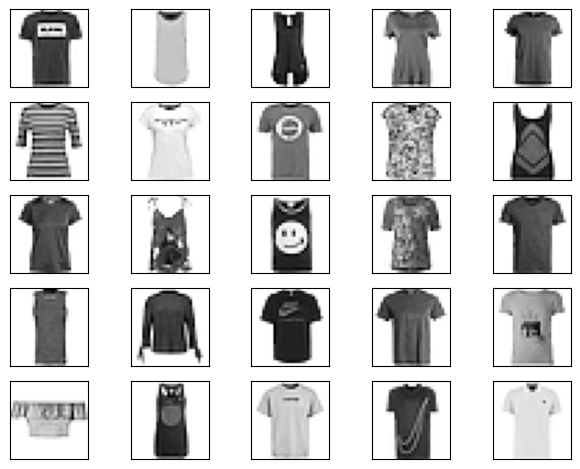

In [60]:
# plot multiple examples of the same digit
fig, ax = plt.subplots(nrows=5, ncols=5, sharex=True, sharey=True,)
ax = ax.flatten()
for i in range(25):
    img = X_train[y_train == 0][i].reshape(28, 28)
    ax[i].imshow(img, cmap='Greys')

ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
# plt.savefig('images/12_6.png', dpi=300)
plt.show()

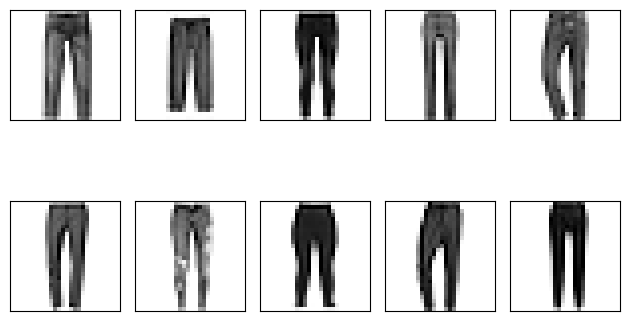

In [61]:
fig, ax = plt.subplots(nrows=2, ncols=5, sharex=True, sharey=True)
ax = ax.flatten()
for i in range(10):
  img = X_train[y_train == 1][i].reshape(28,28)
  ax[i].imshow(img, cmap='Greys')
ax[0].set_xticks([])
ax[0].set_yticks([])
plt.tight_layout()
plt.show()

In [62]:
from re import X
import numpy as np

np.savez_compressed('save_data/mnist_scaled.npz',
                    X_train=X_train,
                    y_train=y_train,
                    X_test=X_test,
                    y_test=y_test)

In [63]:
!ls save_data

mnist_scaled.npz


In [64]:
mnist = np.load('save_data/mnist_scaled.npz')

In [65]:
mnist.files

['X_train', 'y_train', 'X_test', 'y_test']

In [66]:
X_train = mnist['X_train']
X_train

array([[-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       ...,
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.],
       [-1., -1., -1., ..., -1., -1., -1.]])

In [67]:
X_train, y_train, X_test, y_test = [mnist[f] for f in mnist.files]

In [68]:
y_train_5 = (y_train == 4)
y_test_5 = (y_test == 4)

In [69]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(max_iter=1000, tol=0.00001, random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42, tol=1e-05)

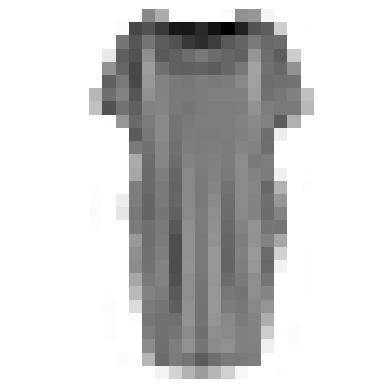

In [70]:
import matplotlib
import matplotlib.pyplot as plt

some_digit = X_train[41000]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation='nearest')
plt.axis('off')
plt.show()


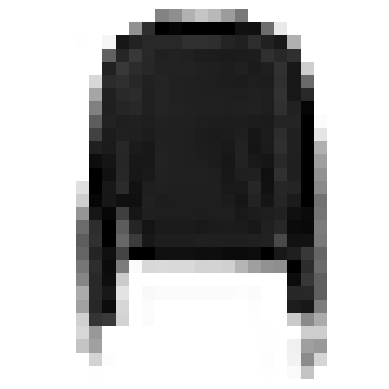

In [71]:
import matplotlib
import matplotlib.pyplot as plt

some_digit = X_train[36000]
some_digit_image = some_digit.reshape(28, 28)

plt.imshow(some_digit_image, cmap=matplotlib.cm.binary, interpolation = "nearest")
plt.axis("off")
plt.show()

In [72]:
sgd_clf.predict([some_digit])

array([ True])

In [73]:
from sklearn.model_selection import cross_val_score
#sacamos la exactitud 
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring='accuracy')

array([0.9463 , 0.95045, 0.94305])

In [74]:
#sacamos promedio
suma = (0.9463 + 0.95045 + 0.94305)/3
print(suma)

0.9814833333333333


In [75]:
#se utiliza para realizar la validación cruzada de un estimador (clasificador en este caso) utilizando una métrica específica
cross_val_score(sgd_clf, X_train, y_train_5, cv=5, scoring='accuracy')

array([0.94816667, 0.90933333, 0.94525   , 0.95025   , 0.94158333])

In [77]:
#sacamos el promedio
suma = (0.94816667 + 0.90933333 + 0.94525  + 0.95025  + 0.94158333)/5
print(suma)

0.9389166660000001
